In [1]:
import pandas as pd
import numpy as np

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "kmeans_sonuclari.xlsx"
CIKTI_DOSYASI = "karar_destek_sonuclari.xlsx"

df = pd.read_excel(GIRIS_DOSYASI)

# ==============================
# GEREKLİ SÜTUN KONTROLÜ
# ==============================

gerekli_sutunlar = [
    "ürün_adı",
    "marka",
    "fiyat_sayisal",
    "puan_sayisal",
    "yorum_sayisi_sayisal",
    "pozitiflik_orani",
    "risk_orani",
    "ek_urun_sayisi",
    "kume_etiketi",
    "ürün_linki"
]

for col in gerekli_sutunlar:
    if col not in df.columns:
        print(f"Uyarı: {col} sütunu bulunamadı.")


# ==============================
# GÜVENLİ NORMALİZASYON
# ==============================

def normalize(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series([0.5] * len(series), index=series.index)

    return (series - min_val) / (max_val - min_val)


df["fiyat_norm"] = 1 - normalize(df["fiyat_sayisal"])
df["puan_norm"] = normalize(df["puan_sayisal"])
df["yorum_norm"] = normalize(df["yorum_sayisi_sayisal"])
df["pozitiflik_norm"] = normalize(df["pozitiflik_orani"])
df["risk_norm"] = 1 - normalize(df["risk_orani"])
df["ek_urun_norm"] = normalize(df["ek_urun_sayisi"])


# ==============================
# KARAR DESTEK SKORU
# ==============================

df["karar_destek_skoru"] = (
    df["fiyat_norm"] * 0.25 +
    df["puan_norm"] * 0.25 +
    df["yorum_norm"] * 0.15 +
    df["pozitiflik_norm"] * 0.20 +
    df["risk_norm"] * 0.10 +
    df["ek_urun_norm"] * 0.05
)

# 0-100 arası skor
df["karar_destek_skoru"] = df["karar_destek_skoru"] * 100


# ==============================
# ÖNERİ LİSTELERİ
# ==============================

en_iyi_genel = df.sort_values(
    "karar_destek_skoru",
    ascending=False
).head(10)

en_iyi_fiyat_performans = df[
    df["fiyat_segmenti"].isin(["Ekonomik", "Orta Segment"])
].sort_values(
    "karar_destek_skoru",
    ascending=False
).head(10)

premium_oneriler = df[
    df["fiyat_segmenti"] == "Premium"
].sort_values(
    "karar_destek_skoru",
    ascending=False
).head(10)

dusuk_riskli_urunler = df.sort_values(
    ["risk_orani", "puan_sayisal"],
    ascending=[True, False]
).head(10)

riskli_urunler = df.sort_values(
    ["risk_orani", "puan_sayisal"],
    ascending=[False, True]
).head(10)

ek_urunlu_firsatlar = df[
    df["ek_urun_sayisi"] > 0
].sort_values(
    "karar_destek_skoru",
    ascending=False
).head(10)


# ==============================
# EXCEL'E ÇOKLU SAYFA OLARAK KAYDET
# ==============================

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="tum_urunler_skorlu", index=False)
    en_iyi_genel.to_excel(writer, sheet_name="en_iyi_genel", index=False)
    en_iyi_fiyat_performans.to_excel(writer, sheet_name="fiyat_performans", index=False)
    premium_oneriler.to_excel(writer, sheet_name="premium_oneriler", index=False)
    dusuk_riskli_urunler.to_excel(writer, sheet_name="dusuk_riskli", index=False)
    riskli_urunler.to_excel(writer, sheet_name="riskli_urunler", index=False)
    ek_urunlu_firsatlar.to_excel(writer, sheet_name="ek_urunlu_firsatlar", index=False)

print("Karar destek sistemi tamamlandı.")
print("Dosya oluşturuldu:", CIKTI_DOSYASI)

print("\nEn iyi genel 10 ürün:")
print(en_iyi_genel[["ürün_adı", "marka", "fiyat_sayisal", "puan_sayisal", "karar_destek_skoru"]])

Karar destek sistemi tamamlandı.
Dosya oluşturuldu: karar_destek_sonuclari.xlsx

En iyi genel 10 ürün:
                                              ürün_adı   marka  fiyat_sayisal  \
79   Asus Vivobook 15, Core i3-1315U, 8GB RAM, 512G...    Asus       28499.00   
78   Asus Vivobook 15, Core i3-1315U, 12GB RAM, 512...    Asus       30554.44   
46   Asus Vivobook 15, Core i3-1315U, 16GB RAM, 512...    Asus       31665.56   
8    Apple MacBook Air M4 16GB 256GB SSD macOS 13" ...   Apple       49999.00   
48   Lenovo Ideapad Slim 3 16IRH10 Intel Core i5 13...  Lenovo       31999.00   
55   Huawei Matebook D16 2024 Intel Core i5 13420H ...  Huawei       41898.98   
89   Apple MacBook Air M4 16GB 512GB SSD macOS 13" ...   Apple       62270.00   
44   Apple MacBook Air M4 16GB 256GB SSD macOS 13" ...   Apple       50015.37   
167  Apple MacBook Air M4 24GB 512GB SSD macOS 13" ...   Apple       72677.76   
258  Apple MacBook Air M4 16GB 512GB SSD macOS 13" ...   Apple       63499.00   

     

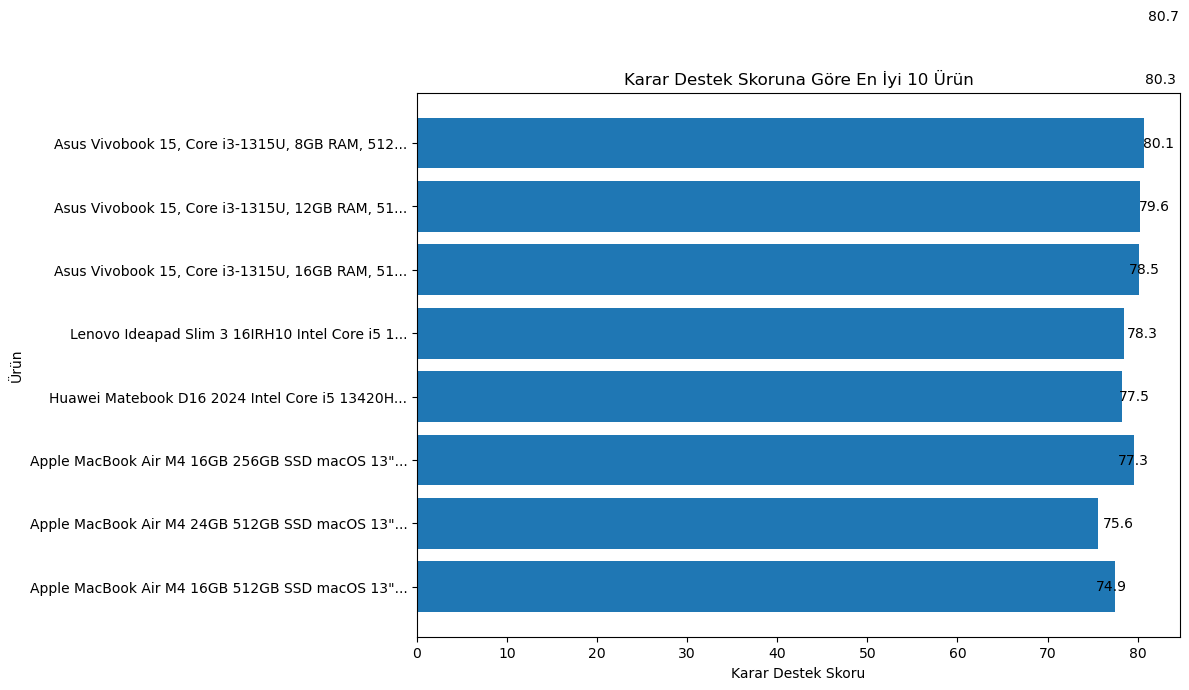

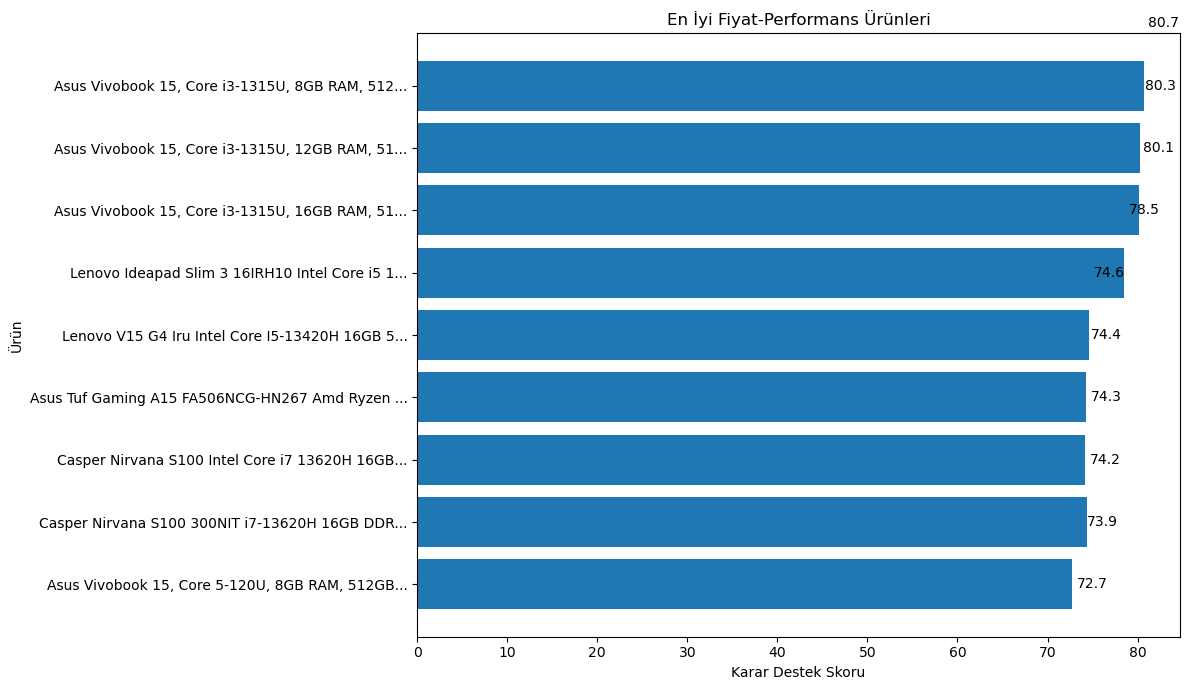

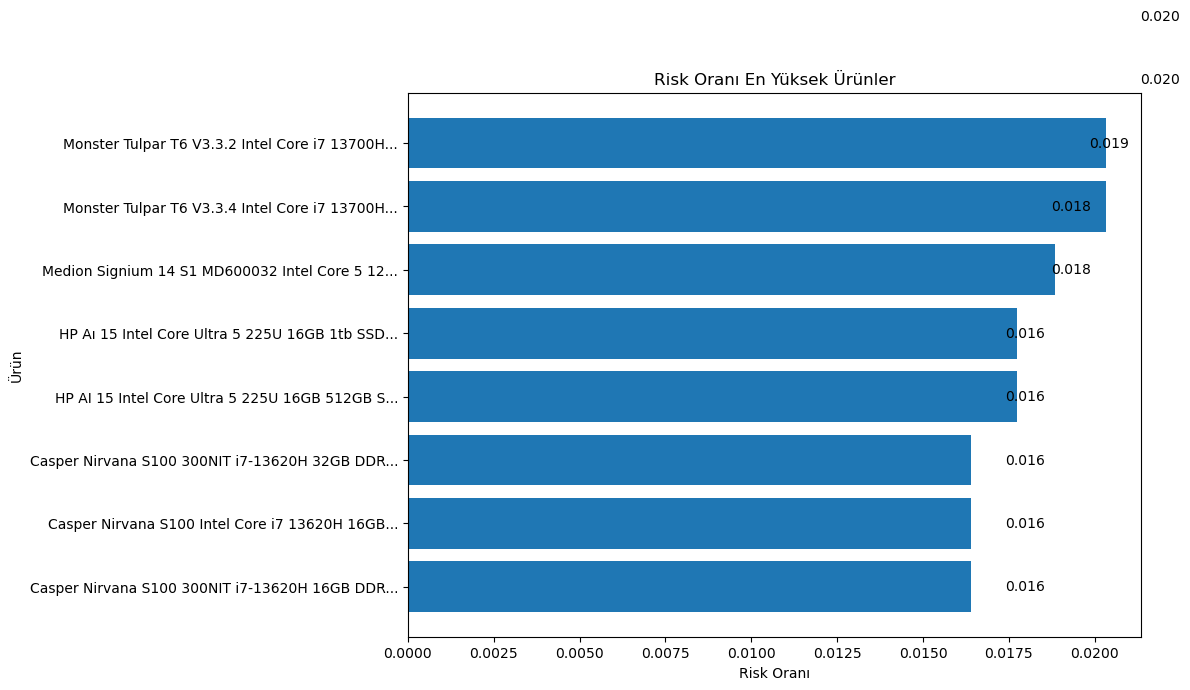

Karar destek grafikleri oluşturuldu:
grafikler/en_iyi_10_urun.png
grafikler/fiyat_performans_onerileri.png
grafikler/riskli_urunler.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "karar_destek_sonuclari.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)


# ==============================
# YARDIMCI FONKSİYON
# ==============================

def urun_adi_kisalt(ad, uzunluk=45):
    ad = str(ad)
    if len(ad) > uzunluk:
        return ad[:uzunluk] + "..."
    return ad


def yatay_bar_grafik(df, baslik, dosya_adi):
    df = df.copy()

    df["kisa_urun_adi"] = df["ürün_adı"].apply(urun_adi_kisalt)

    df = df.sort_values("karar_destek_skoru", ascending=True)

    plt.figure(figsize=(12, 7))

    plt.barh(
        df["kisa_urun_adi"],
        df["karar_destek_skoru"]
    )

    plt.title(baslik)
    plt.xlabel("Karar Destek Skoru")
    plt.ylabel("Ürün")

    for index, value in enumerate(df["karar_destek_skoru"]):
        plt.text(
            value + 0.5,
            index,
            f"{value:.1f}",
            va="center"
        )

    plt.tight_layout()
    plt.savefig(f"{CIKTI_KLASORU}/{dosya_adi}", dpi=300)
    plt.show()


# ==============================
# EXCEL SAYFALARINI OKU
# ==============================

en_iyi_genel = pd.read_excel(
    GIRIS_DOSYASI,
    sheet_name="en_iyi_genel"
)

fiyat_performans = pd.read_excel(
    GIRIS_DOSYASI,
    sheet_name="fiyat_performans"
)

riskli_urunler = pd.read_excel(
    GIRIS_DOSYASI,
    sheet_name="riskli_urunler"
)


# ==============================
# GRAFİKLER
# ==============================

yatay_bar_grafik(
    en_iyi_genel,
    "Karar Destek Skoruna Göre En İyi 10 Ürün",
    "en_iyi_10_urun.png"
)

yatay_bar_grafik(
    fiyat_performans,
    "En İyi Fiyat-Performans Ürünleri",
    "fiyat_performans_onerileri.png"
)

# Riskli ürünlerde skor yerine risk oranı daha anlamlı
riskli_urunler = riskli_urunler.copy()
riskli_urunler["kisa_urun_adi"] = riskli_urunler["ürün_adı"].apply(urun_adi_kisalt)

riskli_urunler = riskli_urunler.sort_values(
    "risk_orani",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    riskli_urunler["kisa_urun_adi"],
    riskli_urunler["risk_orani"]
)

plt.title("Risk Oranı En Yüksek Ürünler")
plt.xlabel("Risk Oranı")
plt.ylabel("Ürün")

for index, value in enumerate(riskli_urunler["risk_orani"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/riskli_urunler.png", dpi=300)
plt.show()


print("Karar destek grafikleri oluşturuldu:")
print(f"{CIKTI_KLASORU}/en_iyi_10_urun.png")
print(f"{CIKTI_KLASORU}/fiyat_performans_onerileri.png")
print(f"{CIKTI_KLASORU}/riskli_urunler.png")